In [1]:
import torch
import json
import warnings
from types import SimpleNamespace  # argparse를 대체하기 위해 import
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import matplotlib.image as mpimg
from io import BytesIO
import re
import pickle
from sklearn.metrics import precision_score, recall_score, f1_score
from qwen_vl_utils import process_vision_info
from config import update_config
from util import str2bool, make_folder  # str2bool은 필요시 사용, make_folder는 유지
from llm_set.basic_func import prompt_selection, llm_selection, print_prompt, inference

warnings.filterwarnings('ignore')

In [2]:
def show_pil_image(image):
    plt.close()
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

def make_ts_image(length, values, label=None, show_gt=False):
    plt.clf()
    plt.figure(figsize=(12, 2))
    plt.plot([num for num in range(length)],[score for score in values]) 
    if show_gt:
        anomalies_idx = [i for i,l in enumerate(label) if l==1] 
        plt.bar(anomalies_idx, 2, bottom=-1, width=1, color='green',alpha=0.5, label='Ground-truth') 
    plt.tight_layout()
    
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight') 
    buf.seek(0)
    plt.close()
    pil_image = Image.open(buf)
    return pil_image

def make_ts_image_for_testing(length, values, predicted, label, precision, recall, f1score):
    predicted_idx = [i for i,l in enumerate(predicted) if l==1] 
    anomalies_idx = [i for i,l in enumerate(label) if l==1] 

    plt.clf()
    plt.figure(figsize=(24, 4))
    plt.plot([num for num in range(length)],[score for score in values]) 
    plt.bar(predicted_idx, 1, bottom=0, width=1, color='red',alpha=0.5, label=f'Predicted') 
    plt.bar(anomalies_idx, 2, bottom=-1, width=1, color='green',alpha=0.5, label='Ground-truth') 
    plt.plot([], [], ' ', label=f'Precision: {precision:.2f}')
    plt.plot([], [], ' ', label=f'Recall: {recall:.2f}')
    plt.plot([], [], ' ', label=f'F1 Score: {f1score:.2f}')
    plt.xlabel("Time", fontsize=20)
    plt.ylabel("Value", fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    plt.legend(fontsize=24, loc='upper left')
    plt.tight_layout()
    
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight') 
    buf.seek(0)
    plt.close()
    pil_image = Image.open(buf)
    return pil_image

In [3]:
# argparse를 대체하는 설정 객체 생성
args = SimpleNamespace(
    # --- 기본 설정 (필요시 수정) ---
    dataset='synthetic',
    class_name='point',
    prompt_ver=0,          # 0: default, 1: CoT
    llm_model=0,           # 0: Qwen, 1: MiniCPM
    
    # --- 기타 설정 (기본값 유지) ---
    set_image=False,
    anomaly_detect=True,   # 추론을 실행해야 하므로 True로 유지
    visualization=True,
    top_k=-1,
    group_length=-1,
    interval=-1,
    grouping=False
)

# 설정 업데이트 및 폴더 생성
cfg = update_config(args)
cfg.print_cfg()
make_folder(cfg)

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(f"Using device: {device}")


------------------------------configutation------------------------------
data_root: ./data
dataset_name: synthetic
class_name: point
set_image: False
anomaly_detect: True
visualization: True
prompt_ver: 0
llm_model: 0
top_k: -1
group_length: -1
interval: -1
grouping: False
data_path: ./data/synthetic/point/eval/data.pkl

Using device: cuda


In [10]:
print("Loading model and prompt...")

# 프롬프트 선택
prompt = prompt_selection(cfg)

# LLM 모델 로드
# llm_selection이 모델 로딩, 토크나이저, 이미지 프로세서 등을 포함하는 
# 'model_set' 객체를 반환한다고 가정합니다.
model_set, processor, model = llm_selection(cfg, device)

print("Model and prompt loaded successfully.")

Loading model and prompt...


OSError: There was a specific connection error when trying to load llm_model/Qwen2-VL-7B-Instruct:
401 Client Error: Unauthorized for url: https://huggingface.co/llm_model/Qwen2-VL-7B-Instruct/resolve/main/config.json (Request ID: Root=1-68f8ca50-52e0fb115eddd7ea024c88d4;8c239d39-8fba-4dff-89e9-65a91339aade)

Invalid credentials in Authorization header

In [5]:

file_path = '/home/inpyo/inpyo/Code-LMTAD-main/data/synthetic/point/eval/data.pkl'
with open(file_path, 'rb') as f:
    data = pickle.load(f)

image_name = file_path.split('/')[-3]
data_length = len(data['series'])
value_list = []
label_list = []

for num in range(data_length):
    org_values = data['series'][num]
    values = [value[0] for value in org_values]

    org_answers = data['anom'][num]
    labels = [0 for _ in range(len(values))]
    for answer in org_answers[0]:
        start, end = answer[0], answer[1] # interval 
        labels[start:end] = [1 for _ in range(start, end)]

    value_list.append(values)
    label_list.append(labels)
    print(num, len(values))

0 1000
1 1000
2 1000
3 1000
4 1000
5 1000
6 1000
7 1000
8 1000
9 1000
10 1000
11 1000
12 1000
13 1000
14 1000
15 1000
16 1000
17 1000
18 1000
19 1000
20 1000
21 1000
22 1000
23 1000
24 1000
25 1000
26 1000
27 1000
28 1000
29 1000
30 1000
31 1000
32 1000
33 1000
34 1000
35 1000
36 1000
37 1000
38 1000
39 1000
40 1000
41 1000
42 1000
43 1000
44 1000
45 1000
46 1000
47 1000
48 1000
49 1000
50 1000
51 1000
52 1000
53 1000
54 1000
55 1000
56 1000
57 1000
58 1000
59 1000
60 1000
61 1000
62 1000
63 1000
64 1000
65 1000
66 1000
67 1000
68 1000
69 1000
70 1000
71 1000
72 1000
73 1000
74 1000
75 1000
76 1000
77 1000
78 1000
79 1000
80 1000
81 1000
82 1000
83 1000
84 1000
85 1000
86 1000
87 1000
88 1000
89 1000
90 1000
91 1000
92 1000
93 1000
94 1000
95 1000
96 1000
97 1000
98 1000
99 1000
100 1000
101 1000
102 1000
103 1000
104 1000
105 1000
106 1000
107 1000
108 1000
109 1000
110 1000
111 1000
112 1000
113 1000
114 1000
115 1000
116 1000
117 1000
118 1000
119 1000
120 1000
121 1000
122 1000
123

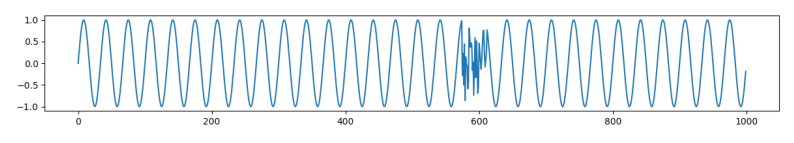

In [6]:
from io import BytesIO
import re

sample_num = 10
sample_length = len(label_list[sample_num])
sample_label = label_list[sample_num]
sample_values = value_list[sample_num]
sample_image = make_ts_image(sample_length, sample_values, sample_label, False)
show_pil_image(sample_image)

In [7]:
messages = [
    {
        "role": "system", 
        "content": "You are a time series anomaly detector."
    },
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": sample_image,
            },
            {
                "type": "text", 
                "text": """\
                    Detect ranges of anomalies in this time series, in terms of the x-axis coordinate.
                    List one by one, in JSON format. 
                    If there are no anomalies, answer with an empty list [].

                    Output template:
                    [{"start": ..., "end": ...}, {"start": ..., "end": ...}...]
                        """
            },
        ],
    }
]

In [8]:


# 단일 추론 실행
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")

generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
try:
    qwen_output = re.findall(r'\[.*?\]', output_text[0])[0]
except:
    qwen_output = '[]'

print(qwen_output)



NameError: name 'processor' is not defined

precision: 0.12
recall: 0.32432432432432434
f1_score: 0.17518248175182483


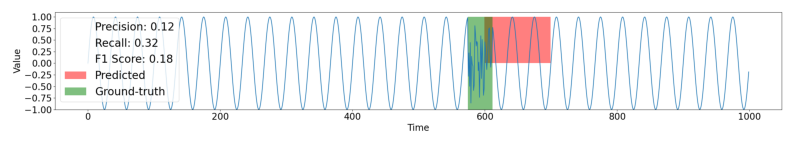

In [23]:
# parsing
parsed = json.loads(qwen_output)
result = [(item["start"], item["end"]) for item in parsed]

# make predicted arr
predicted = [0 for _ in range(sample_length)]
for answer in result:
    start, end = answer[0], answer[1] # interval
    predicted[start:end] = [1 for _ in range(start, end)]

if np.all(np.array(sample_label) == 0) or np.all(np.array(sample_label) == 1):
    predicted = [0]+predicted+[1]
    sample_label = [0]+sample_label+[1]

# evaluation
precision = precision_score(sample_label, predicted)
recall = recall_score(sample_label, predicted)
f1score = f1_score(sample_label, predicted)
print('precision:', precision)
print('recall:', recall)
print('f1_score:', f1score)

# visualization
pred_image = make_ts_image_for_testing(length=sample_length, values=sample_values, predicted=predicted, label=sample_label, precision=precision, recall=recall, f1score=f1score)
show_pil_image(pred_image)